# CT Power Harvest Testing

A current transformer (CT) clamps around a conductor and harvests power from the magnetic field produced by the current flowing through it. The core is made of two halves that close around the conductor and power transfer depends on the magnetic path through those halves being complete which only happens when the faces meet cleanly. Poor contact from insufficient clamping force, core misalignment or debris on the faces introduces an air gap and reduces the power harvested.

This notebook looks at how clamping force affects the power harvested by a nanocrystalline CT. The CT output is passed through a full wave rectifier and smoothing capacitor into a 5 V constant voltage DC load and the current delivered to the load is recorded as force is increased. Power is calculated from that current. 

### Setup

This notebook uses ct_data and ct_plots src/ modules for loading and plotting. 
Analysis logic lives there while narrative is contained in the notebook.

In [41]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


import sys; sys.path.append("../src")
from ct_data import load_trial
from ct_plots import plot_trial, condition_subtitle, source_annotation, compare_trials, compare_trials_dual, date_span_annotation


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
def analyse_trial(trial_id, force_unit="N"):
    df = load_trial(trial_id)
    fig, ax = plot_trial(df, "power_mW", force_unit=force_unit, ylabel="Power (mW)")
    fig.suptitle("CT Power Harvesting with Clamping Force")
    ax.set_title(condition_subtitle(df), fontsize=9)
    fig.savefig(f"../figures/trial_{trial_id}_power_vs_force.png",
                dpi=300, bbox_inches="tight")
    fig.text(0.02, -0.02, source_annotation(df), ha="left",
         fontsize=8, color="gray")
    return df, fig, ax

### Trial 003 - Nanocrystalline (0-10N)

**Test setup:**

The upper half of the test jig was attached to the force gauge so it could be zeroed against the combined weight of the CT and jig. The smaller-range force gauge was used for increased resolution. CT was connected to full wave rectifier, with 40uF of capacitance for smoothing then connected to a 5V constant voltage DC load was applied in place of a fixed resistance and a nanocrystalline CT was used. The chart below shows output current against applied force under these conditions. 

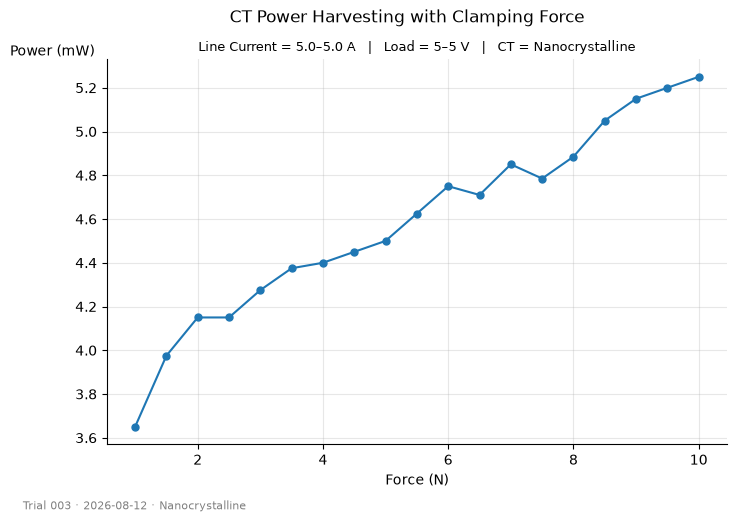

In [43]:
df3, _, _ = analyse_trial("003")

**Findings:**

Power increased with clamping force applied. The test was stopped at 10 N due to approaching the max limit of the high resolution force gauge.

**Sources of error:**

- The jig seems to have some level of interference where some of the force is translated through the alignment features rather than the CT cores.

- In the larger force gauge test metal particles had formed and collected on the CT core faces preventing good contact to be made. This needs to be understood better (how it occurs, how to prevent it).

### Trial 004 - Nanocrystalline (0-300N)

**Test setup:**

The fixtures holding the CT cores were redesigned to eliminate points of interference. This ensured all clamping force was translated directly through the CT cores.
A larger force gauge was installed to allow testing up to 300 N.

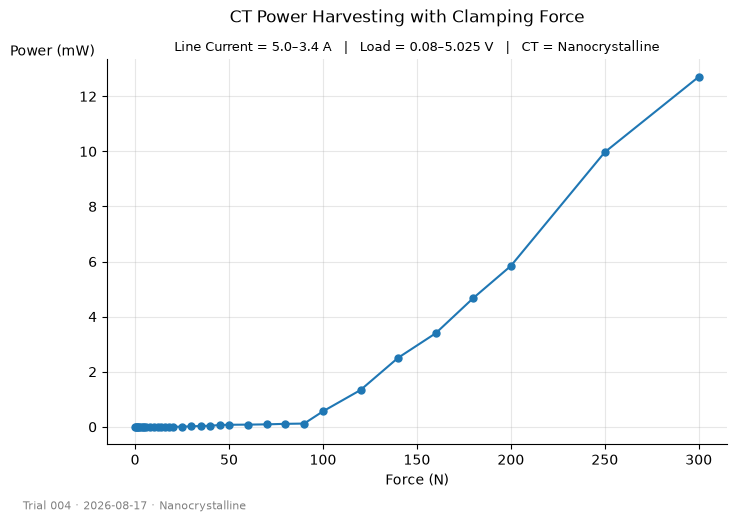

In [44]:
df4, _, _ = analyse_trial("004")

**Findings:**

The results should have repeated the findings from trial 003 from 0 to 10 N. In practice no significant power was generated until ~90 N. After this it ramped up fairly linearly until 300 N where it approached the force gauge limit. 

**Sources of error:**

- Debris remains on the exposed core surfaces. Cleaning with alcohol and blotting paper revealed metal particles which could be creating an air gap.

- Jig constraint. The upper half of the jig does not appear perfectly parallel with the lower jig. This results in some of the CT core touching before the rest producing reduced contact area. 

### Trial 005 - Nanocrystalline (0-300N)

**Test setup:**

The conditions were kept the same as trial 004 however the CT cores were removed, and cleaned. The cleaning procedure involved applying adhesive tape to the exposed core to pick up any debris. Subsequently isopropyl alcohol was applied with paper towel to remove any residual adhesive from the tape.

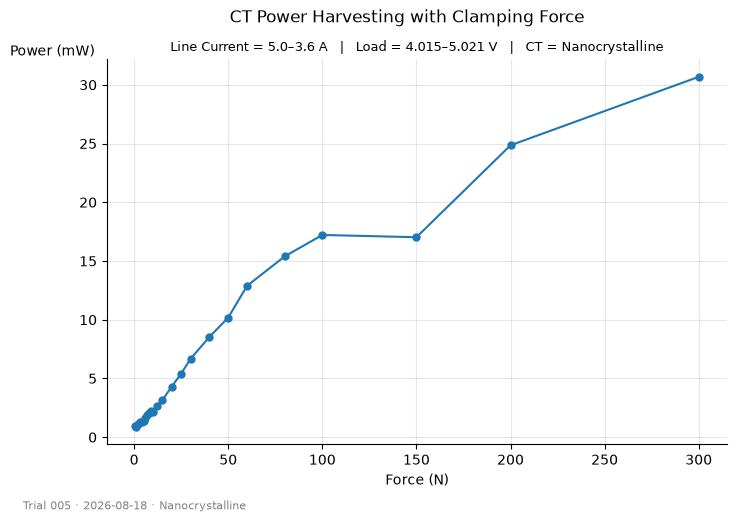

In [45]:
df5, _, _ = analyse_trial("005")

### Trial 006 - Nanocrystalline (0-400N Force Gauge)

**Test setup:**

The conditions were kept the same as trials 004 and 004 however the CT was swapped for another sample. The sample has the same size, specifications and was from the same order.

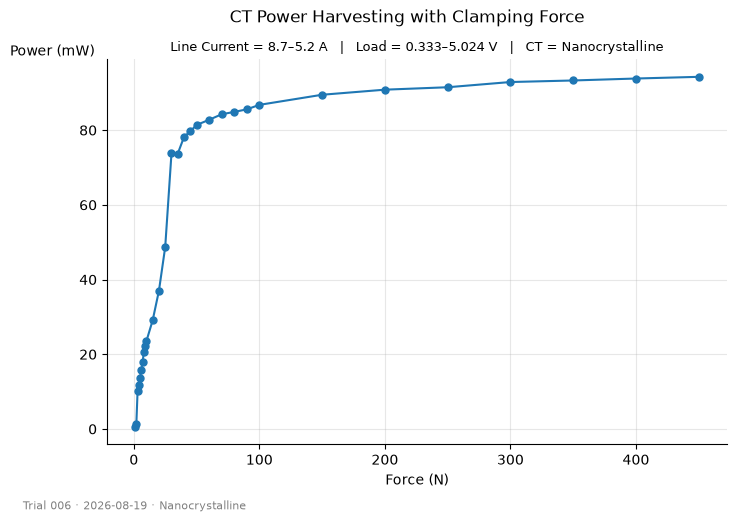

In [46]:
df6, _, _ = analyse_trial("006")

### Comparing Trials 003, 004, 005 and 006

Three trials of the same CT have now delivered a range of results. The trials are compared below:

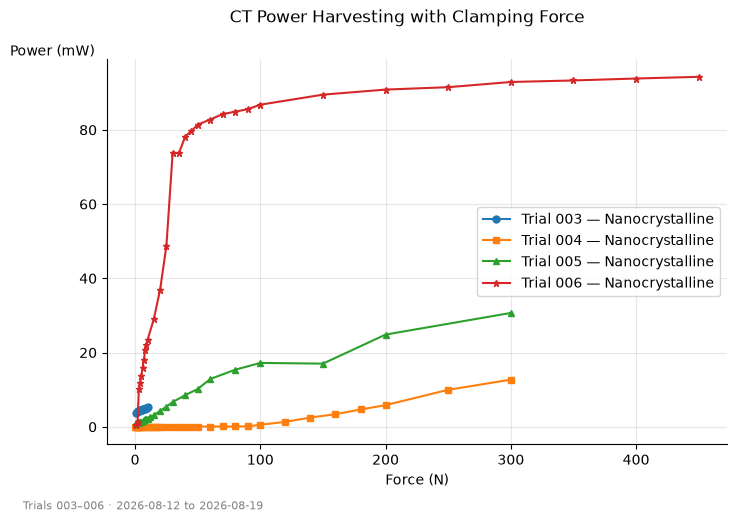

In [47]:
# single panel, full range
fig, ax = compare_trials(["003", "004", "005", "006"])
fig.suptitle("CT Power Harvesting with Clamping Force")
fig.savefig("../figures/compare_003_006_full.png", dpi=300, bbox_inches="tight")
plt.show()

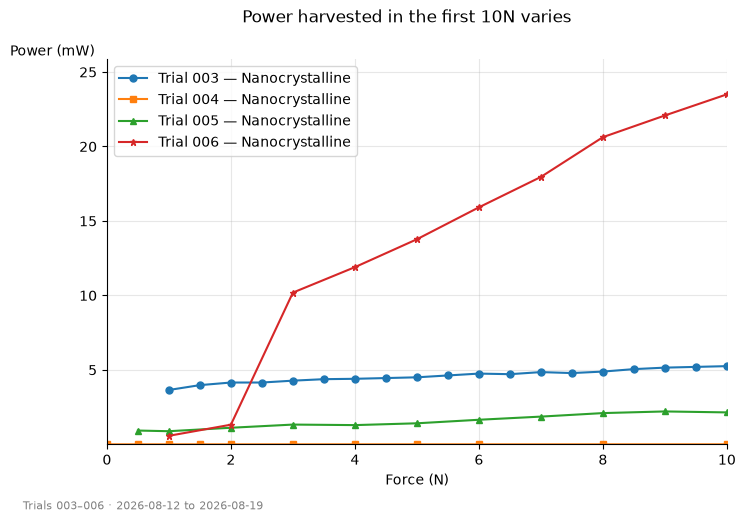

In [48]:
# single panel, zoomed to 0–10 N
fig, ax = compare_trials(["003", "004", "005", "006"], xlim=(0, 10))
fig.suptitle("Power harvested in the first 10N varies")
fig.savefig("../figures/compare_003_006_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

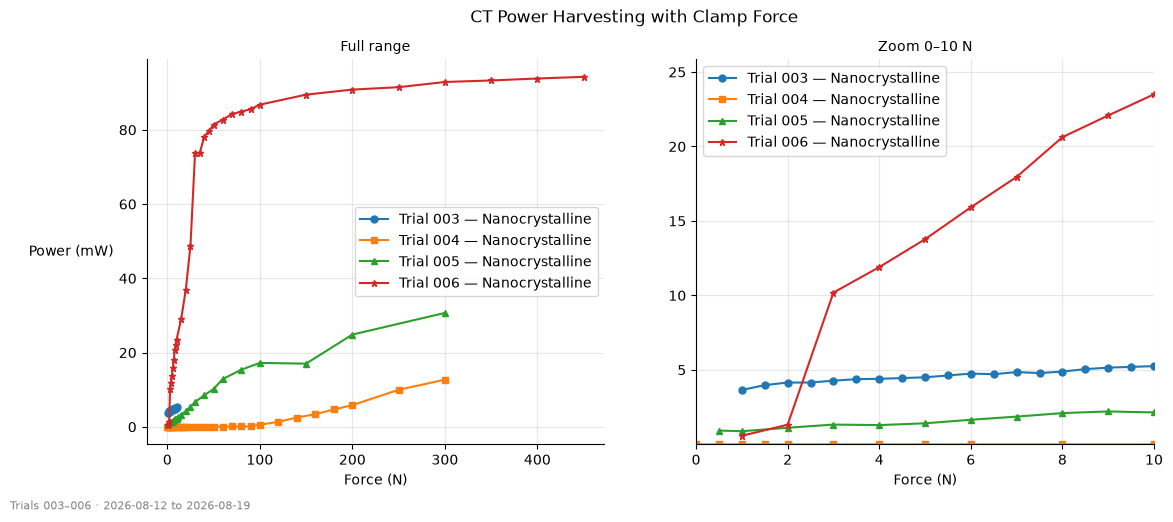

In [49]:
# dual panel, full + zoom side by side
fig, (ax_full, ax_zoom) = compare_trials_dual(["003", "004", "005", "006"])
fig.suptitle("CT Power Harvesting with Clamp Force")
fig.savefig("../figures/compare_003_006_dual.png", dpi=300, bbox_inches="tight")
plt.show()

**Findings:**


The variation seen in the three trials suggests something else is changing between the tests. This could be the alignment of the CT cores in the fixture, the condition of the surfaces of the CT cores or something else entirely.

It may not be realistic to expect directly repeatable relationships between clamping force and power harvesting. Regardless the results are clear that, in non-ideal circumstances increasing clamping force results in increased power harvesting. 

### Next steps

- Test full Overhead Line Sensor devices on the same test setup under the same conditions and comapre the power harvesting. Use this to assess if the enclosure has been getting the full harvesting potential out of the CT.